In [1]:
from src import pre_processor_inferencia
import joblib
import pandas as pd
from scipy.stats import norm
import random

In [2]:
def pipeline_aluno(dt_presenca, dt_desempenho, dados_aluno):
    
    df = pd.DataFrame([dados_aluno])
    X  = pre_processor_inferencia(df)

    # Probabilidades de presença
    prob_presenca = dt_presenca.predict_proba(X)[0]
    presenca      = dt_presenca.predict(X)[0]

    resultado = {
        'presenca':         'presente' if presenca == 1 else 'ausente',
        'prob_presente':    f'{prob_presenca[1]:.1%}',
        'prob_ausente':     f'{prob_presenca[0]:.1%}',
        'desempenho':       None,
        'prob_acima':       None,
        'prob_abaixo':      None,
    }

    if presenca == 1:
        prob_desempenho = dt_desempenho.predict_proba(X)[0]
        desempenho      = dt_desempenho.predict(X)[0]

        resultado['desempenho']  = 'acima da mediana' if desempenho == 1 else 'abaixo da mediana'
        resultado['prob_acima']  = f'{prob_desempenho[1]:.1%}'
        resultado['prob_abaixo'] = f'{prob_desempenho[0]:.1%}'

    return resultado

In [3]:
def chances_por_curso(prob_acima: float, desvio=0.10):
    cursos = {
    'Medicina (top)'        : 0.97, 
    'Direito (top)'         : 0.90,
    'Computação (top)'      : 0.85,
    'Engenharia'            : 0.74,
    'Administração'         : 0.65,
    'Pedagogia'             : 0.54,
    'Licenciaturas'         : 0.53,
    'Tecnólogos'            : 0.49,
    'Cursos noturnos'       : 0.42,
}
    resultado = {}
    for curso, percentil_corte in cursos.items():
        # Probabilidade do aluno superar o corte dado a incerteza
        z = (prob_acima - percentil_corte) / desvio
        chance = norm.cdf(z)
        resultado[curso] = f'{chance:.1%}'
        
    return resultado

In [4]:
def gerar_aluno_aleatorio():
    return {
        'Q001': random.choice(list('ABCDEFGH')),
        'Q002': random.choice(list('ABCDEFGH')),
        'Q003': random.choice(list('ABCDEF')),
        'Q004': random.choice(list('ABCDEF')),
        'Q005': random.randint(1,20 ),
        'Q006': random.choice(list('ABCDEFGHIJKLMNOPQ')),
        'Q007': random.choice(list('ABCD')),
        'Q008': random.choice(list('ABCDE')),
        'Q009': random.choice(list('ABCDE')),
        'Q010': random.choice(list('ABCDE')),
        'Q011': random.choice(list('ABCDE')),
        'Q012': random.choice(list('ABCDE')),
        'Q013': random.choice(list('ABCDE')),
        'Q014': random.choice(list('ABCDE')),
        'Q015': random.choice(list('ABCDE')),
        'Q016': random.choice(list('ABCDE')),
        'Q017': random.choice(list('ABCDE')),
        'Q018': random.choice(list('ABCDE')),
        'Q019': random.choice(list('ABCDE')),
        'Q020': random.choice(list('ABCDE')),
        'Q021': random.choice(list('ABCDE')),
        'Q022': random.choice(list('ABCDE')),
        'Q023': random.choice(list('ABCDE')),
        'Q024': random.choice(list('ABCDE')),
        'Q025': random.choice(list('AB')),
        'TP_FAIXA_ETARIA':        random.randint(1, 10),
        'TP_ESTADO_CIVIL':        random.randint(1, 4),
        'TP_ESCOLA':              random.choice([2, 3]),
        'TP_ST_CONCLUSAO':        random.randint(1, 4),
        'IN_TREINEIRO':           random.choice([0, 1]),
        'NU_ANO':                 random.choice([2019, 2020, 2021, 2022, 2023]),
        'TP_DEPENDENCIA_ADM_ESC': random.randint(1, 4),
        'TP_LOCALIZACAO_ESC':     random.choice([1, 2]),
        'TP_SIT_FUNC_ESC':        random.randint(1, 3),
    }

In [5]:
rf_presenca   = joblib.load('models/rf_presenca_teste.pkl')
rf_desempenho = joblib.load('models/rf_desempenho.pkl')

In [6]:
resultados = []

for i in range(10):
    aluno = gerar_aluno_aleatorio()
    resultado = pipeline_aluno(rf_presenca, rf_desempenho, aluno)
    resultados.append(resultado)
    print(f'Aluno {i+1}: {resultado}')

Aluno 1: {'presenca': 'presente', 'prob_presente': '52.9%', 'prob_ausente': '47.1%', 'desempenho': 'abaixo da mediana', 'prob_acima': '49.5%', 'prob_abaixo': '50.5%'}
Aluno 2: {'presenca': 'presente', 'prob_presente': '68.2%', 'prob_ausente': '31.8%', 'desempenho': 'abaixo da mediana', 'prob_acima': '43.2%', 'prob_abaixo': '56.8%'}
Aluno 3: {'presenca': 'ausente', 'prob_presente': '22.9%', 'prob_ausente': '77.1%', 'desempenho': None, 'prob_acima': None, 'prob_abaixo': None}
Aluno 4: {'presenca': 'ausente', 'prob_presente': '40.6%', 'prob_ausente': '59.4%', 'desempenho': None, 'prob_acima': None, 'prob_abaixo': None}
Aluno 5: {'presenca': 'ausente', 'prob_presente': '34.5%', 'prob_ausente': '65.5%', 'desempenho': None, 'prob_acima': None, 'prob_abaixo': None}
Aluno 6: {'presenca': 'presente', 'prob_presente': '62.6%', 'prob_ausente': '37.4%', 'desempenho': 'abaixo da mediana', 'prob_acima': '28.3%', 'prob_abaixo': '71.7%'}
Aluno 7: {'presenca': 'presente', 'prob_presente': '67.0%', 'pro

In [7]:
alunos_acima = [r for r in resultados if r['desempenho'] != None]
print(f'\nAlunos com desempenho acima da mediana: {len(alunos_acima)}')


Alunos com desempenho acima da mediana: 6


In [8]:
alunos_acima

[{'presenca': 'presente',
  'prob_presente': '52.9%',
  'prob_ausente': '47.1%',
  'desempenho': 'abaixo da mediana',
  'prob_acima': '49.5%',
  'prob_abaixo': '50.5%'},
 {'presenca': 'presente',
  'prob_presente': '68.2%',
  'prob_ausente': '31.8%',
  'desempenho': 'abaixo da mediana',
  'prob_acima': '43.2%',
  'prob_abaixo': '56.8%'},
 {'presenca': 'presente',
  'prob_presente': '62.6%',
  'prob_ausente': '37.4%',
  'desempenho': 'abaixo da mediana',
  'prob_acima': '28.3%',
  'prob_abaixo': '71.7%'},
 {'presenca': 'presente',
  'prob_presente': '67.0%',
  'prob_ausente': '33.0%',
  'desempenho': 'abaixo da mediana',
  'prob_acima': '43.9%',
  'prob_abaixo': '56.1%'},
 {'presenca': 'presente',
  'prob_presente': '62.9%',
  'prob_ausente': '37.1%',
  'desempenho': 'acima da mediana',
  'prob_acima': '56.6%',
  'prob_abaixo': '43.4%'},
 {'presenca': 'presente',
  'prob_presente': '54.9%',
  'prob_ausente': '45.1%',
  'desempenho': 'acima da mediana',
  'prob_acima': '72.8%',
  'prob_a

In [9]:
for i, aluno in enumerate(alunos_acima):
    prob = float(aluno['prob_acima'].strip('%')) / 100
    
    print(f'\n===== Aluno {i+1} =====')
    print(f"Presença: {aluno['presenca']} ({aluno['prob_presente']})")
    print(f"Desempenho: {aluno['desempenho']} | Prob. acima: {aluno['prob_acima']}")
    print(f"\nChances por curso:")
    
    for curso, chance in chances_por_curso(prob).items():
        print(f'  {curso:<25} {chance}')



===== Aluno 1 =====
Presença: presente (52.9%)
Desempenho: abaixo da mediana | Prob. acima: 49.5%

Chances por curso:
  Medicina (top)            0.0%
  Direito (top)             0.0%
  Computação (top)          0.0%
  Engenharia                0.7%
  Administração             6.1%
  Pedagogia                 32.6%
  Licenciaturas             36.3%
  Tecnólogos                52.0%
  Cursos noturnos           77.3%

===== Aluno 2 =====
Presença: presente (68.2%)
Desempenho: abaixo da mediana | Prob. acima: 43.2%

Chances por curso:
  Medicina (top)            0.0%
  Direito (top)             0.0%
  Computação (top)          0.0%
  Engenharia                0.1%
  Administração             1.5%
  Pedagogia                 14.0%
  Licenciaturas             16.4%
  Tecnólogos                28.1%
  Cursos noturnos           54.8%

===== Aluno 3 =====
Presença: presente (62.6%)
Desempenho: abaixo da mediana | Prob. acima: 28.3%

Chances por curso:
  Medicina (top)            0.0%
  Direit

In [17]:
aluno = { 'Q001': 'H', 'Q002': 'G', 'Q003': 'D', 'Q004': 'D', 'Q005': 4, 'Q006': 'F', 'Q007': 'C', 'Q008': 'D', 'Q009': 'D', 'Q010': 'B', 'Q011': 'E', 'Q012': 'D', 'Q013': 'C', 'Q014': 'C', 'Q015': 'E', 'Q016': 'D', 'Q017': 'C', 'Q018': 'C', 'Q019': 'D', 'Q020': 'C', 'Q021': 'D', 'Q022': 'C', 'Q023': 'C', 'Q024': 'D', 'Q025': 'B', 'TP_FAIXA_ETARIA': 3, 'TP_ESTADO_CIVIL': 1, 'TP_ESCOLA': 3, 'TP_ST_CONCLUSAO': 1, 'IN_TREINEIRO': 0, 'NU_ANO': 2022, 'TP_DEPENDENCIA_ADM_ESC': 4, 'TP_LOCALIZACAO_ESC': 1, 'TP_SIT_FUNC_ESC': 1, }
resultado = pipeline_aluno(rf_presenca, rf_desempenho, aluno)
print(resultado)

{'presenca': 'ausente', 'prob_presente': '24.5%', 'prob_ausente': '75.5%', 'desempenho': None, 'prob_acima': None, 'prob_abaixo': None}


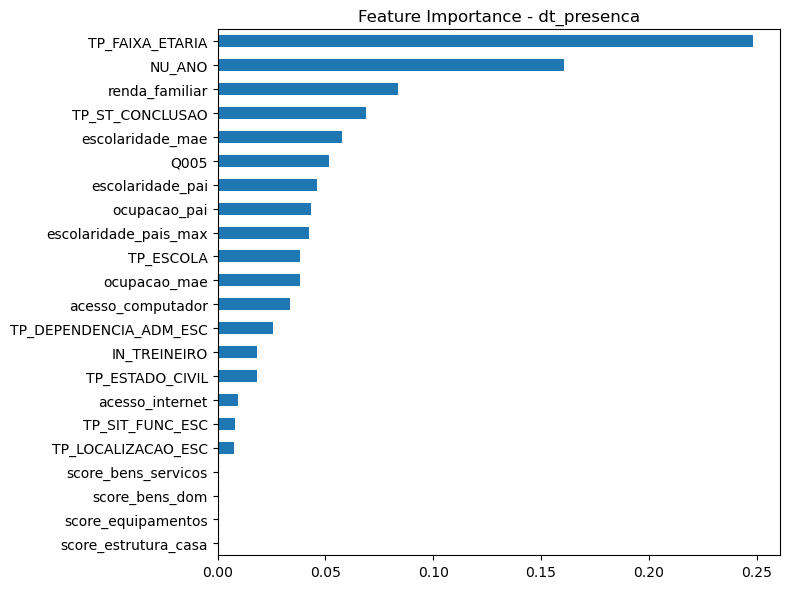

TP_FAIXA_ETARIA     0.248408
NU_ANO              0.160542
renda_familiar      0.083694
TP_ST_CONCLUSAO     0.068916
escolaridade_mae    0.057652
dtype: float64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt

features = ['Q005', 'TP_FAIXA_ETARIA', 'TP_ESTADO_CIVIL', 'TP_ESCOLA', 
            'TP_ST_CONCLUSAO', 'IN_TREINEIRO', 'NU_ANO', 'TP_LOCALIZACAO_ESC', 
            'TP_SIT_FUNC_ESC', 'TP_DEPENDENCIA_ADM_ESC', 'escolaridade_pai', 
            'escolaridade_mae', 'escolaridade_pais_max', 'ocupacao_pai', 
            'ocupacao_mae', 'renda_familiar', 'score_bens_servicos', 
            'score_bens_dom', 'score_equipamentos', 'score_estrutura_casa', 
            'acesso_computador', 'acesso_internet']

importancias = pd.Series(rf_presenca.feature_importances_, index=features)
importancias.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Feature Importance - dt_presenca')
plt.tight_layout()
plt.show()

print(importancias.sort_values(ascending=False).head(5))